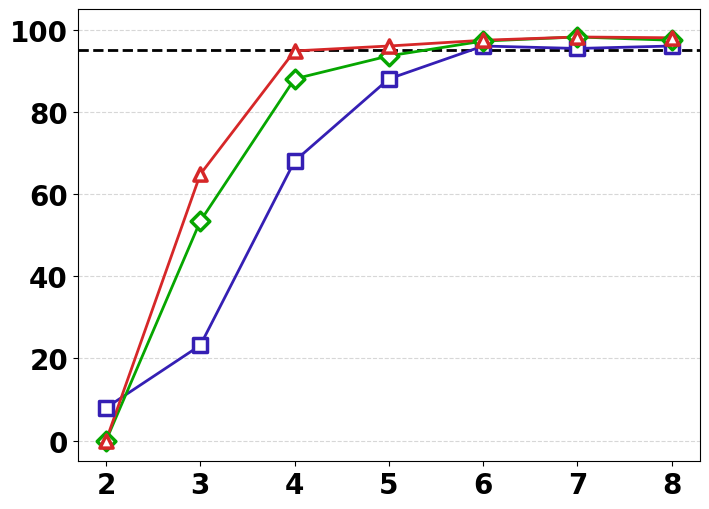

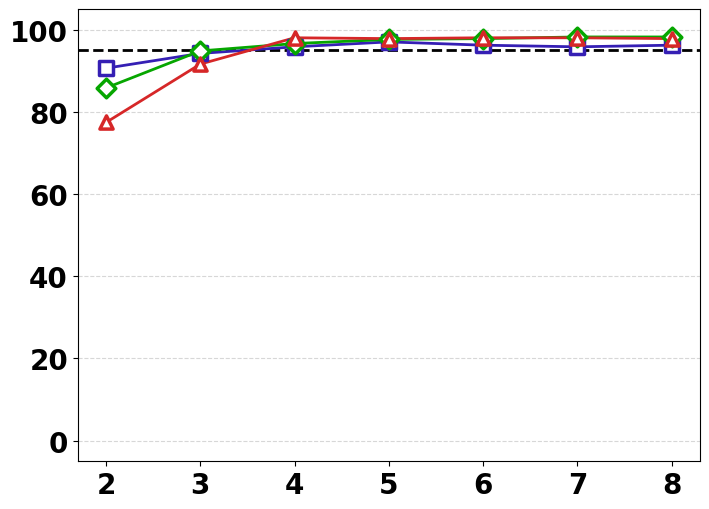

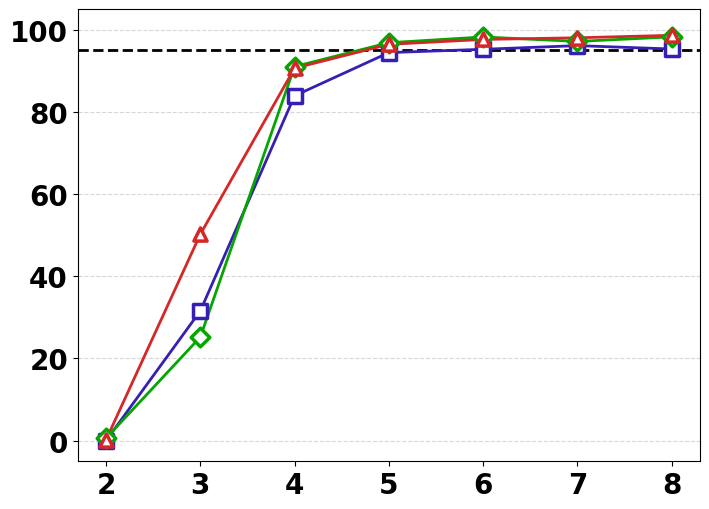

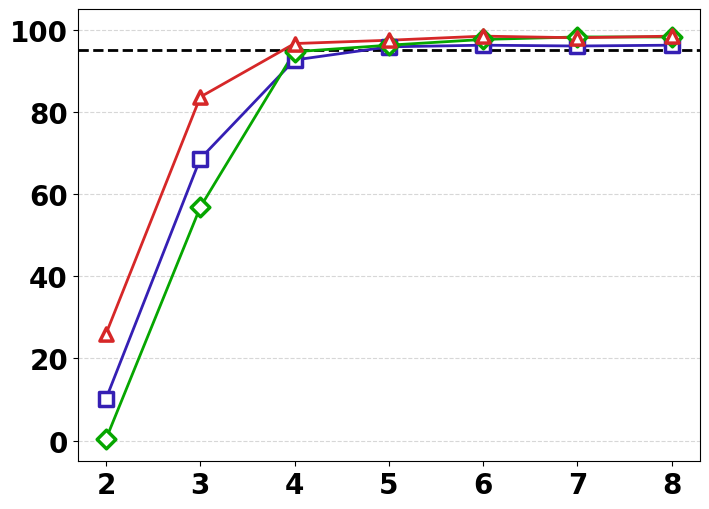

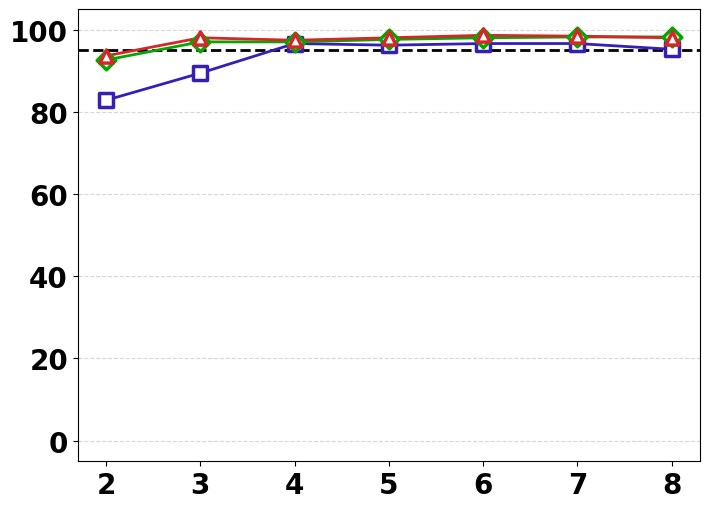

In [5]:
import pandas as pd
import glob
import re
import matplotlib.pyplot as plt
import numpy as np

# --- パターン定義（この順で図が出る） ---
patterns = [
    "/work/robomimic/csv/eval/lift/quantize/weight/unit*.csv",
    "/work/robomimic/csv/eval/lift/quantize/LUT/unit*.csv",
    "/work/robomimic/csv/eval/lift/quantize/CAM/calibration/u*.csv",
    "/work/robomimic/csv/eval/lift/quantize/digital/calibration/u*.csv",
    "/work/robomimic/csv/eval/lift/quantize/digital/fixed/u*.csv",
]

def extract_bit(filename: str):
    m = re.search(r"quantized_(\d+)bit", filename)
    return int(m.group(1)) if m else None

def extract_base_model(name: str):
    # seed 除去
    name = re.sub(r"_seed\d+", "", name)

    # quantized_xbit 以降を除去
    name = re.sub(r"_?quantized[_\-]?\d+\s*bit.*", "", name)

    # unit64 → u64 正規化
    name = name.replace("unit64", "u64")
    name = name.replace("unit128", "u128")
    name = name.replace("unit256", "u256")

    return name

# --- 描画設定 ---
custom_colors = {
    "ncp_u64_best":  "#351fb4",
    "u64":      "#351fb4",
    "ncp_u128_best": "#06a600",
    "u128":     "#06a600",
    "ncp_u256_best": "#d62728",
    "u256":     "#d62728",
}

markers = {
    "ncp_u64_best":  "s",
    "u64":      "s",
    "ncp_u128_best": "D",
    "u128":     "D",
    "ncp_u256_best": "^",
    "u256":     "^",
}

plot_order = ["ncp_u64_best","u64", "ncp_u128_best", "u128", "ncp_u256_best", "u256"]

# ===============================
# pattern ごとに「順番に」描画
# ===============================
for pattern in patterns:

    csv_files = sorted(glob.glob(pattern))
    if len(csv_files) == 0:
        continue

    df_list = []
    for file in csv_files:
        bit = extract_bit(file)
        if bit is None:
            continue
        df = pd.read_csv(file)
        df["bit"] = bit
        df["base_model"] = df["name"].apply(extract_base_model)
        df_list.append(df)

    if len(df_list) == 0:
        continue

    df_all = pd.concat(df_list, ignore_index=True)

    # --- 集計 ---
    df_agg = (
        df_all.groupby(["base_model", "bit"])["success_rate"]
              .mean()
              .reset_index()
    )
    df_agg = df_agg[df_agg["bit"] != 1]

    # ===== 描画 =====
    plt.figure(figsize=(7.2, 5.2))

    # 95% 基準線（背面）
    plt.axhline(
        95,
        color="black",
        linestyle="--",
        linewidth=2.0,
        zorder=-10,
    )

    for base_model in plot_order:
        df_m = df_agg[df_agg["base_model"] == base_model].sort_values("bit")
        if df_m.empty:
            continue

        bits  = df_m["bit"].values
        means = df_m["success_rate"].values * 100

        color  = custom_colors[base_model]
        marker = markers[base_model]

        plt.plot(bits, means, color=color, linewidth=2.0, zorder=5)
        plt.scatter(
            bits, means,
            marker=marker,
            s=90,
            facecolors="white",
            edgecolors=color,
            linewidths=2.5,
            zorder=6,
        )

    plt.ylim(-5, 105)
    plt.xticks(sorted(df_agg["bit"].unique()))

    plt.tick_params(axis="both", labelsize=20)
    for lbl in plt.gca().get_xticklabels() + plt.gca().get_yticklabels():
        lbl.set_fontweight("bold")

    plt.grid(axis="y", linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()
